Nama : Rangga Saputra

NIM : 250401020034

Kelas : IF405

---

# Praktikum Pertemuan 11: Unsupervised Learning: Clustering (K-Means & Hierarchical)

## Langkah 1: Generate & Eksplorasi Dataset

Membuat dataset sintetis pelanggan dengan tiga kelompok tersembunyi (hemat, menengah, boros), kemudian melakukan eksplorasi data (EDA) singkat untuk melihat sebaran data sebelum clustering dilakukan.

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


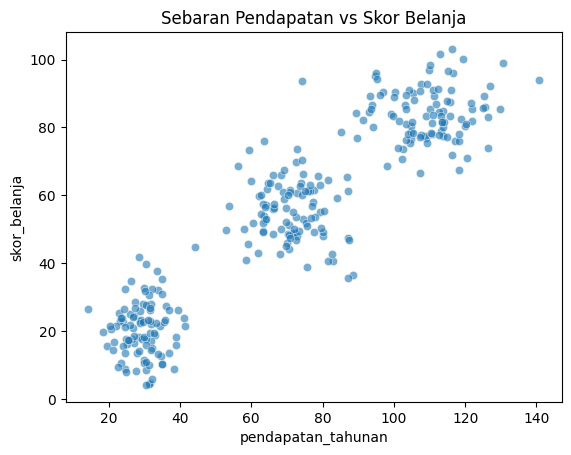

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))    # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

Dataset berisi 300 baris data pelanggan sintetis dengan rata-rata pendapatan tahunan sekitar 70 juta rupiah (rentang ±14–141 juta) dan rata-rata skor belanja sekitar 53 (rentang ±4–103). Dari scatter plot terlihat tiga kerumunan (kelompok) data yang cukup terpisah secara visual. Hal ini konsisten dengan tiga kelompok tersembunyi (hemat, menengah, boros) yang sengaja dibentuk saat generate data, meskipun label kelompok tersebut belum diketahui oleh algoritma.

## Langkah 2: Preprocessing Data

Memilih fitur numerik yang relevan (`pendapatan_tahunan` dan `skor_belanja`), kemudian menerapkan **StandardScaler** agar kedua fitur memiliki skala yang setara. Preprocessing ini penting karena K-Means bekerja berdasarkan jarak Euclidean, sehingga fitur dengan skala lebih besar (mis. pendapatan) tidak boleh mendominasi perhitungan jarak dibanding fitur dengan skala lebih kecil (mis. skor belanja).

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling     :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling     : [1. 1.]


**Note:** Setelah scaling, rata-rata (mean) kedua fitur menjadi 0 dan standar deviasi menjadi 1, sehingga kedua fitur berada pada skala yang setara dan siap digunakan untuk perhitungan jarak pada K-Means.

## Langkah 3: Metode Elbow untuk Menentukan K

Menjalankan K-Means untuk K = 1 hingga 10, menyimpan nilai WCSS (`inertia_`) setiap K, lalu memplot grafik Elbow untuk menentukan jumlah cluster yang optimal.

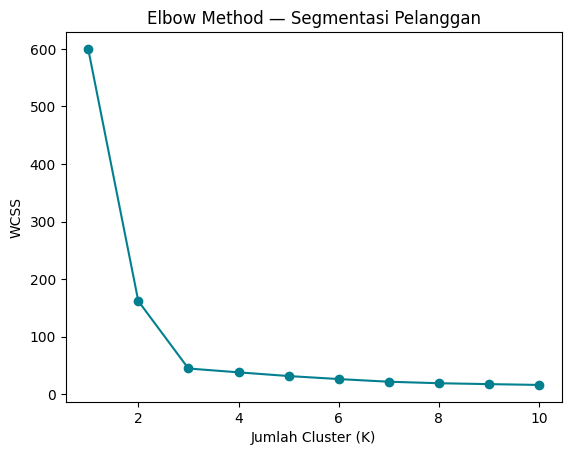

WCSS per K: [600.0, 161.73, 44.56, 37.88, 31.45, 26.2, 21.56, 18.96, 17.39, 16.01]


In [3]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()

print('WCSS per K:', [round(w, 2) for w in wcss])

- Nilai WCSS turun sangat tajam dari K=1 (± 600) ke K=2 (± 162) dan ke K=3 (± 45).
- Setelah K=3, penurunan WCSS mulai melandai (K=4 ± 38, K=5 ± 31, dan seterusnya menurun secara bertahap dan kecil).
- Titik siku (elbow) paling jelas terlihat pada **K = 3**, sehingga K=3 dipilih sebagai jumlah cluster optimal.
- Hasil ini **sesuai dengan jumlah kelompok yang diharapkan**, karena dataset memang sengaja dibuat dengan tiga kelompok tersembunyi (hemat, menengah, boros).

## Langkah 4: Melatih Model K-Means

Melatih model K-Means dengan K=3 (hasil pengamatan grafik Elbow pada Langkah 3), lalu menampilkan nilai WCSS akhir, Silhouette Score, dan rata-rata fitur tiap cluster sebagai bahan interpretasi.

In [4]:
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))
print(df['cluster'].value_counts())

WCSS akhir      : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08
cluster
2    101
1    100
0     99
Name: count, dtype: int64


- WCSS akhir untuk K=3 sekitar **44,6**, jauh lebih rendah dibanding K=1 namun tetap merepresentasikan struktur data dengan jumlah cluster yang sederhana.
- Silhouette Score sekitar **0,70** menunjukkan cluster yang terbentuk **sangat baik** (mendekati +1, jauh dari cluster tetangga), lebih tinggi dibanding K=2 (0,63) maupun K=4 (0,58). Ini menjadi bukti tambahan bahwa K=3 adalah pilihan optimal, sesuai rekomendasi pada Sub-bab 6.3 modul untuk membandingkan Silhouette Score di antara kandidat K.
- Ketiga cluster memiliki jumlah anggota yang relatif seimbang (± 99–101 pelanggan per cluster), dengan rata-rata karakteristik sebagai berikut:
  - Cluster dengan pendapatan & skor belanja terendah: segmen **Hemat**
  - Cluster dengan pendapatan & skor belanja menengah: segmen **Menengah**
  - Cluster dengan pendapatan & skor belanja tertinggi: segmen **Boros/Premium**

## Langkah 5: Visualisasi Hasil Clustering

Membuat scatter plot berwarna per cluster beserta posisi centroid (ditandai simbol X merah), kemudian menginterpretasikan karakteristik tiap segmen pelanggan.

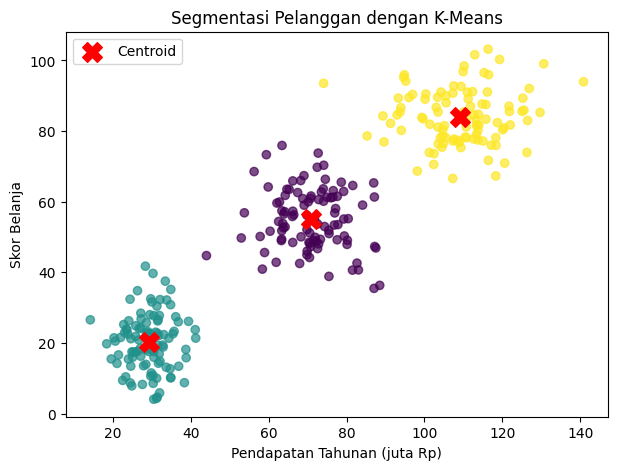

In [5]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()

- **Cluster 0** → pendapatan & skor belanja menengah (rata-rata ± 71 juta / skor ± 55) → segmen **"Menengah"**.
- **Cluster 1** → pendapatan & skor belanja rendah (rata-rata ± 29 juta / skor ± 20) → segmen **"Hemat"**.
- **Cluster 2** → pendapatan & skor belanja tinggi (rata-rata ± 109 juta / skor ± 84) → segmen **"Boros/Premium"**.

Ketiga centroid (titik X merah) berada tepat di tengah masing-masing kerumunan data, menunjukkan bahwa K-Means berhasil menemukan pusat kelompok yang representatif untuk tiap segmen. Secara bisnis, hasil ini dapat digunakan misalnya untuk merancang strategi pemasaran yang berbeda bagi tiap segmen: promosi hemat untuk Cluster 1, program loyalitas untuk Cluster 0, dan penawaran produk premium untuk Cluster 2.

## Langkah 6: Hierarchical Clustering (Pembanding)

Sebagai pembanding terhadap hasil K-Means, dibangun dendrogram menggunakan **Ward linkage**, kemudian hasilnya dibandingkan dengan jumlah cluster optimal dari Metode Elbow pada Langkah 3.

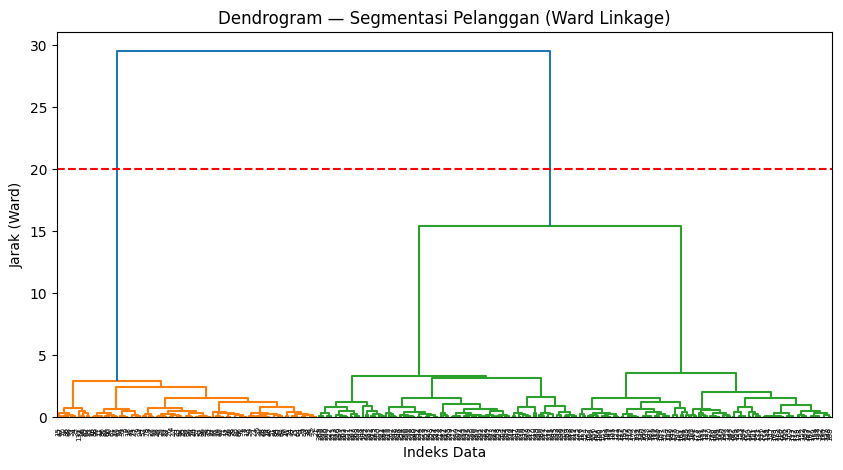

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=20, color='red', linestyle='--')  # garis potong untuk 3 cluster
plt.show()

**Perbandingan dengan hasil Metode Elbow:**

Dendrogram menunjukkan tiga penggabungan terakhir terjadi pada ketinggian yang jauh berbeda: dua cluster kecil bergabung di ketinggian ± 15,4, lalu penggabungan akhir menjadi satu cluster besar terjadi di ketinggian ± 29,6. Terdapat celah vertikal yang cukup lebar di antara kedua ketinggian tersebut, sehingga garis potong horizontal diletakkan di sekitar jarak **20** (di antara ± 15,4 dan ± 29,6).

Memotong dendrogram pada ketinggian tersebut menghasilkan **3 cluster**, yang **konsisten dengan K optimal (K=3) hasil Metode Elbow** pada Langkah 3. Kedua pendekatan Partitional (K-Means) dan Hierarchical saling memperkuat kesimpulan bahwa data pelanggan pada dataset ini paling alami dikelompokkan menjadi tiga segmen: Hemat, Menengah, dan Boros/Premium.

## Kesimpulan

1. Dataset pelanggan sintetis berhasil dikelompokkan menjadi 3 segmen menggunakan K-Means Clustering, sesuai dengan tiga kelompok tersembunyi yang dibentuk saat generate data.
2. Metode Elbow menunjukkan titik siku yang jelas pada K=3, dan Silhouette Score tertinggi (± 0,70) juga diperoleh pada K=3, sehingga kedua metode saling mendukung dalam menentukan K optimal.
3. Hierarchical Clustering dengan Ward linkage menghasilkan pembagian cluster yang konsisten dengan hasil K-Means, memperkuat validitas segmentasi yang diperoleh.
4. Ketiga segmen pelanggan (Hemat, Menengah, Boros/Premium) dapat dijadikan dasar strategi pemasaran yang lebih tertarget bagi masing-masing kelompok pelanggan.